# HW4: Meta-Analysis of Crohn's Disease Microbiome
## Pipeline: Cohort selection → Harmonisation → Batch effect check → Meta-analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


Libraries loaded.


## Task 1 — Step 1: Load data and select Crohn's disease cohorts

In [ ]:
# This file contains metadata columns + species abundance columns (s__ prefix)
df = pd.read_csv('/home/valerie/Desktop/Master/metagenomics/HW3/input/cron_data.csv') 

print(f'Total samples loaded: {len(df)}')
print(f'Columns: {df.shape[1]}')
print(df['subject_disease_status'].value_counts())

Total samples loaded: 5150
Columns: 3827
subject_disease_status
CTR                4259
Crohn's disease     891
Name: count, dtype: int64


In [3]:
# Extract study_id from sample_alias (format: StudyName_Year_Cohort.sample_XXX)
df['study_id'] = df['sample_alias'].str.split('.').str[0]
df['study_id'] = df['study_id'].apply(lambda x: '_'.join(x.split('_')[:3]))

study_summary = df.groupby('study_id')['subject_disease_status'].value_counts().unstack(fill_value=0)
study_summary['total'] = study_summary.sum(axis=1)

print('\nStudy composition (disease status per study):')
print(study_summary.to_string())


Study composition (disease status per study):
subject_disease_status        CTR  Crohn's disease  total
study_id                                                 
Bai_2021_HIV                   11                0     11
Barone_2022_obesity            16                0     16
Bedarf_2017_Parkinson          28                0     28
Boktor_2022_PD                116                0    116
Bramble_2021_konzo             18                0     18
Braun_2024_Crohn               21               17     38
Buschart_2016_T1D              10                0     10
Bushman_2020_pediatric         27                0     27
Chen_2022_Parkinson            21                0     21
DeFillipis_2019_diet          101                0    101
Duan_2020_CDI                   5                0      5
Fan_2023_anorexia              70                0     70
Gevers_2014_Crohn               0               13     13
Hale_2018_CRC                  11                0     11
He_2017_Crohn            

In [7]:
# Select cohorts that have BOTH Crohn's disease AND CTR samples
# and a minimum sample size threshold (>=10 per group) for reliable regression
MIN_PER_GROUP = 10

if "Crohn's disease" in study_summary.columns and 'CTR' in study_summary.columns:
    eligible = study_summary[
        (study_summary["Crohn's disease"] >= MIN_PER_GROUP) &
        (study_summary['CTR'] >= MIN_PER_GROUP)
    ]
else:
    raise ValueError('Expected columns not found — check disease status labels')

selected_cohorts = eligible.index.tolist()
print(f'\nCohorts eligible for meta-analysis (>=10 per group): {len(selected_cohorts)}')
print(eligible[['CTR', "Crohn's disease", 'total']])

# Filter dataframe to eligible cohorts only
df_meta = df[df['study_id'].isin(selected_cohorts)].copy()
print(f'\nSamples retained for meta-analysis: {len(df_meta)}')


Cohorts eligible for meta-analysis (>=10 per group): 3
subject_disease_status  CTR  Crohn's disease  total
study_id                                           
Braun_2024_Crohn         21               17     38
He_2017_Crohn            54               62    116
Kumbhari_2024_IBD        54              234    288

Samples retained for meta-analysis: 442


## Step 2: Data harmonisation

In [8]:
# --- Species abundance matrix ---
species_cols_raw = [col for col in df_meta.columns if col.startswith('s__')]

# Clean and deduplicate species names (same logic as HW3)
clean_names = {col: col.split('.')[0].split('_SGB')[0] for col in species_cols_raw}
abundance_raw = df_meta[species_cols_raw].rename(columns=clean_names)
abundance_raw = abundance_raw.T.groupby(level=0).sum().T

# --- Harmonisation: filter to species present in >= 10% of samples across the meta-cohort ---
prevalence = (abundance_raw > 0).mean(axis=0)
mean_abund  = abundance_raw.mean(axis=0)
keep_mask   = (prevalence >= 0.10) & (mean_abund >= 0.001)
abundance_filtered = abundance_raw.loc[:, keep_mask]

print(f'Species before filtering : {abundance_raw.shape[1]}')
print(f'Species after filtering  : {abundance_filtered.shape[1]}')

# --- CLR transformation ---
pseudocount = 1e-6
abundance_pseudo = abundance_filtered + pseudocount
log_data = np.log(abundance_pseudo)
clr_abundance = log_data.sub(log_data.mean(axis=1), axis=0)

# --- Rebuild analysis dataframe ---
metadata_cols = [c for c in df_meta.columns if not c.startswith('s__')]
meta_df = df_meta[metadata_cols].reset_index(drop=True)
clr_df  = clr_abundance.reset_index(drop=True)

final_df = pd.concat([meta_df, clr_df], axis=1)
final_df['is_crohns'] = (final_df['subject_disease_status'] == "Crohn's disease").astype(int)

print(f'\nFinal harmonised dataset: {final_df.shape[0]} samples, {clr_df.shape[1]} species')

Species before filtering : 3314
Species after filtering  : 302

Final harmonised dataset: 442 samples, 302 species


## Step 3: Batch effect check (PCA coloured by study)

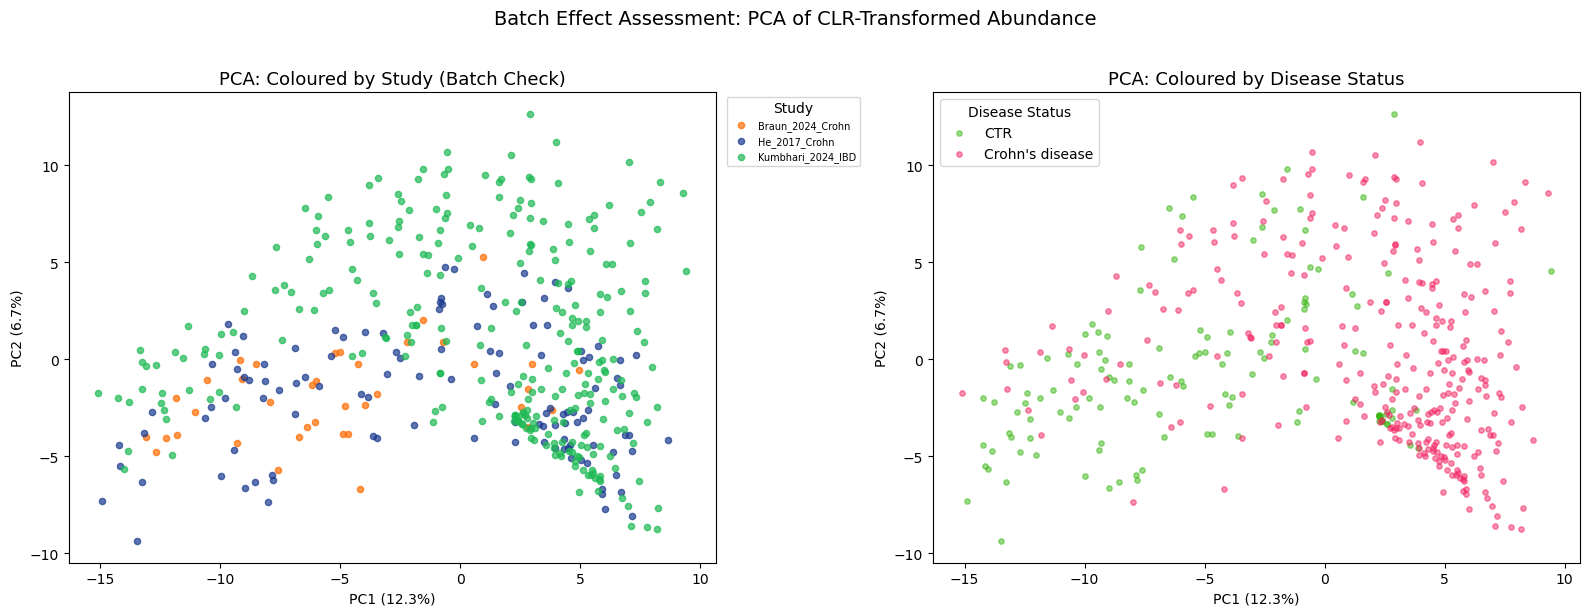

In [ ]:
# PCA on CLR-transformed abundance to visualise batch effects
scaler = StandardScaler()
clr_scaled = scaler.fit_transform(clr_df.fillna(0))

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(clr_scaled)

pca_plot_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'study_id': final_df['study_id'].values,
    'disease': final_df['subject_disease_status'].values
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: coloured by study (to detect batch effects)
studies = pca_plot_df['study_id'].unique()
study_colors = {
    'Braun_2024_Crohn' : '#FF6B00',   # vivid orange
    'He_2017_Crohn'    : '#1A3A8F',   # dark blue
    'Kumbhari_2024_IBD': '#1DB954',   # strong green
}
for i, study in enumerate(studies):
    sub = pca_plot_df[pca_plot_df['study_id'] == study]
    axes[0].scatter(sub['PC1'], sub['PC2'], label=study,
                    color=study_colors.get(study, '#888888'), alpha=0.7, s=20)
axes[0].set_title('PCA: Coloured by Study (Batch Check)', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, title='Study')

# Plot B: coloured by disease status
palette_disease = {"CTR": "#3ab614", "Crohn's disease": "#f32261"}
for group, color in palette_disease.items():
    sub = pca_plot_df[pca_plot_df['disease'] == group]
    axes[1].scatter(sub['PC1'], sub['PC2'], label=group,
                    color=color, alpha=0.5, s=15)
axes[1].set_title('PCA: Coloured by Disease Status', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(title='Disease Status')

plt.suptitle('Batch Effect Assessment: PCA of CLR-Transformed Abundance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/home/valerie/Desktop/Master/metagenomics/HW4/output/PCA.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Uses Bray-Curtis distance on the filtered (non-CLR) abundance
try:
    from skbio.diversity import beta_diversity
    from skbio.stats.distance import permanova

    abund_vals = abundance_filtered.reset_index(drop=True).values
    sample_ids = [str(i) for i in range(len(abund_vals))]
    bc_dm = beta_diversity('braycurtis', abund_vals, ids=sample_ids)

    meta_indexed = final_df.reset_index(drop=True)
    meta_indexed.index = sample_ids

    perm_study   = permanova(bc_dm, meta_indexed, column='study_id',   permutations=999)
    perm_disease = permanova(bc_dm, meta_indexed, column='subject_disease_status', permutations=999)

    print('=== PERMANOVA: Study Effect ===')
    print(f'  Pseudo-F: {perm_study["test statistic"]:.4f},  p = {perm_study["p-value"]:.4f}')
    print('\n=== PERMANOVA: Disease Effect ===')
    print(f'  Pseudo-F: {perm_disease["test statistic"]:.4f},  p = {perm_disease["p-value"]:.4f}')
    print('\nNote: A significant study effect indicates batch effects are present.')
except ImportError:
    print('scikit-bio not available. Skipping PERMANOVA — use PCA plots for batch assessment.')

=== PERMANOVA: Study Effect ===
  Pseudo-F: 8.0031,  p = 0.0010

=== PERMANOVA: Disease Effect ===
  Pseudo-F: 13.1322,  p = 0.0010

Note: A significant study effect indicates batch effects are present.


## Step 4: Meta-analysis

In [16]:
# ============================================================
# STRATEGY A: Pooled linear regression with study as covariate
# (controls for batch effect as a fixed effect)
# ============================================================

species_list = [col for col in final_df.columns if col.startswith('s__')]
print(f'Running pooled MWAS on {len(final_df)} samples, {len(species_list)} species...')

pooled_results = []

for species in species_list:
    formula = f"Q('{species}') ~ is_crohns + C(age_category) + C(sex) + C(study_id)"
    try:
        model = smf.ols(formula, data=final_df).fit()
        pooled_results.append({
            'Species' : species,
            'Beta'    : model.params['is_crohns'],
            'SE'      : model.bse['is_crohns'],
            'P_value' : model.pvalues['is_crohns']
        })
    except Exception:
        continue

pooled_df = pd.DataFrame(pooled_results)
_, fdr_p, _, _ = multipletests(pooled_df['P_value'], method='fdr_bh')
pooled_df['FDR_P'] = fdr_p
pooled_df = pooled_df.sort_values('FDR_P')

n_sig_pooled = (pooled_df['FDR_P'] < 0.05).sum()
print(f'\n[Pooled model] Significant species (FDR < 0.05): {n_sig_pooled}')
print('\nTop 10:')
print(pooled_df.head(10)[['Species', 'Beta', 'SE', 'P_value', 'FDR_P']].to_string(index=False))

Running pooled MWAS on 442 samples, 302 species...

[Pooled model] Significant species (FDR < 0.05): 202

Top 10:
                               Species      Beta       SE      P_value        FDR_P
               s__Clostridium_innocuum  5.521320 0.591093 4.956855e-19 1.496970e-16
     s__Erysipelatoclostridium_ramosum  5.941279 0.690170 1.359819e-16 2.053327e-14
    s__Fusicatenibacter_sp_CLA_AA_H277 -3.182376 0.413852 9.896900e-14 9.962879e-12
                   s__Blautia_producta  4.579742 0.613520 4.576987e-13 2.964905e-11
     s__Enterocloster_clostridioformis  5.137075 0.689586 5.069544e-13 2.964905e-11
                   s__Escherichia_coli  4.964189 0.668383 5.890539e-13 2.964905e-11
         s__Brotolimicola_acetigignens -3.877111 0.528158 1.048582e-12 4.523882e-11
s__Lachnospiraceae_bacterium_AM48_27BH -2.849060 0.406515 9.203564e-12 3.474346e-10
                s__Lachnospira_eligens -3.878857 0.567601 2.796517e-11 9.383868e-10
                s__Ruminococcus_gnavus  4.1343

In [17]:
# ============================================================
# STRATEGY B: Per-cohort MWAS + Random-effects meta-analysis
# (DerSimonian-Laird random-effects model)
# ============================================================

def random_effects_meta(betas, ses):
    """
    DerSimonian-Laird random-effects meta-analysis.
    Input: arrays of per-study beta coefficients and standard errors.
    Returns: pooled beta, SE, z, p-value, tau2 (between-study variance), I2
    """
    betas = np.array(betas)
    ses   = np.array(ses)
    w_fe  = 1 / ses**2                          # fixed-effect weights
    
    # Cochran's Q
    beta_fe = np.sum(w_fe * betas) / np.sum(w_fe)
    Q = np.sum(w_fe * (betas - beta_fe)**2)
    k = len(betas)
    df_Q = k - 1
    
    # Between-study variance tau^2 (DL estimator)
    C = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2 = max(0.0, (Q - df_Q) / C)
    
    # I2 statistic
    I2 = max(0.0, (Q - df_Q) / Q * 100) if Q > 0 else 0.0
    
    # Random-effects weights
    w_re  = 1 / (ses**2 + tau2)
    beta_re = np.sum(w_re * betas) / np.sum(w_re)
    se_re   = np.sqrt(1 / np.sum(w_re))
    z       = beta_re / se_re
    p       = 2 * (1 - stats.norm.cdf(abs(z)))
    
    return beta_re, se_re, z, p, tau2, I2

# --- Per-cohort MWAS ---
cohort_results = {}  # {cohort: DataFrame with Beta, SE, P per species}

for cohort in selected_cohorts:
    cohort_df = final_df[final_df['study_id'] == cohort].copy()
    
    # Only run if both groups are present
    if cohort_df['is_crohns'].nunique() < 2:
        continue
    
    cohort_res = []
    for species in species_list:
        formula = f"Q('{species}') ~ is_crohns + C(age_category) + C(sex)"
        try:
            model = smf.ols(formula, data=cohort_df).fit()
            cohort_res.append({
                'Species': species,
                'Beta'   : model.params['is_crohns'],
                'SE'     : model.bse['is_crohns'],
                'P_value': model.pvalues['is_crohns'],
                'N'      : len(cohort_df)
            })
        except Exception:
            continue
    
    if cohort_res:
        cohort_results[cohort] = pd.DataFrame(cohort_res)

print(f'Per-cohort MWAS complete for {len(cohort_results)} cohorts.')

Per-cohort MWAS complete for 3 cohorts.


In [18]:
# --- Combine per-cohort results using DL random-effects ---
meta_results = []

for species in species_list:
    betas, ses = [], []
    for cohort, res_df in cohort_results.items():
        row = res_df[res_df['Species'] == species]
        if not row.empty and not np.isnan(row['SE'].values[0]) and row['SE'].values[0] > 0:
            betas.append(row['Beta'].values[0])
            ses.append(row['SE'].values[0])
    
    if len(betas) < 2:  # need at least 2 cohorts
        continue
    
    beta_re, se_re, z, p, tau2, I2 = random_effects_meta(betas, ses)
    meta_results.append({
        'Species'   : species,
        'Beta_meta' : beta_re,
        'SE_meta'   : se_re,
        'Z'         : z,
        'P_value'   : p,
        'Tau2'      : tau2,
        'I2'        : I2,
        'N_cohorts' : len(betas)
    })

meta_df = pd.DataFrame(meta_results)
_, fdr_p, _, _ = multipletests(meta_df['P_value'], method='fdr_bh')
meta_df['FDR_P'] = fdr_p
meta_df = meta_df.sort_values('FDR_P')

n_sig_meta = (meta_df['FDR_P'] < 0.05).sum()
print(f'[Random-effects meta-analysis] Significant species (FDR < 0.05): {n_sig_meta}')
print('\nTop 10:')
print(meta_df.head(10)[['Species','Beta_meta','SE_meta','FDR_P','I2','N_cohorts']].to_string(index=False))

[Random-effects meta-analysis] Significant species (FDR < 0.05): 91

Top 10:
                           Species  Beta_meta  SE_meta        FDR_P        I2  N_cohorts
               s__Escherichia_coli   4.610648 0.513890 0.000000e+00  0.000000          3
        s__Faecalimonas_umbilicata   4.360741 0.688000 3.508356e-08  0.000000          3
                        s__GGB9760  -2.559749 0.421167 1.226861e-07  0.000000          3
                        s__GGB9699  -2.461800 0.426296 4.651604e-07  0.000000          3
           s__Clostridium_scindens   3.500171 0.604216 4.651604e-07  0.000000          3
      s__Acidaminococcus_intestini   3.277313 0.579332 7.750980e-07  0.000000          3
            s__Anaerostipes_caccae   3.128648 0.558662 9.234186e-07 21.058346          3
s__Fusicatenibacter_sp_CLA_AA_H277  -3.371089 0.611879 1.359163e-06 47.427123          3
             s__Lactococcus_lactis   2.557413 0.475485 2.519758e-06 45.220269          3
         s__Flavonifractor_plauti

## Step 5: Visualisation

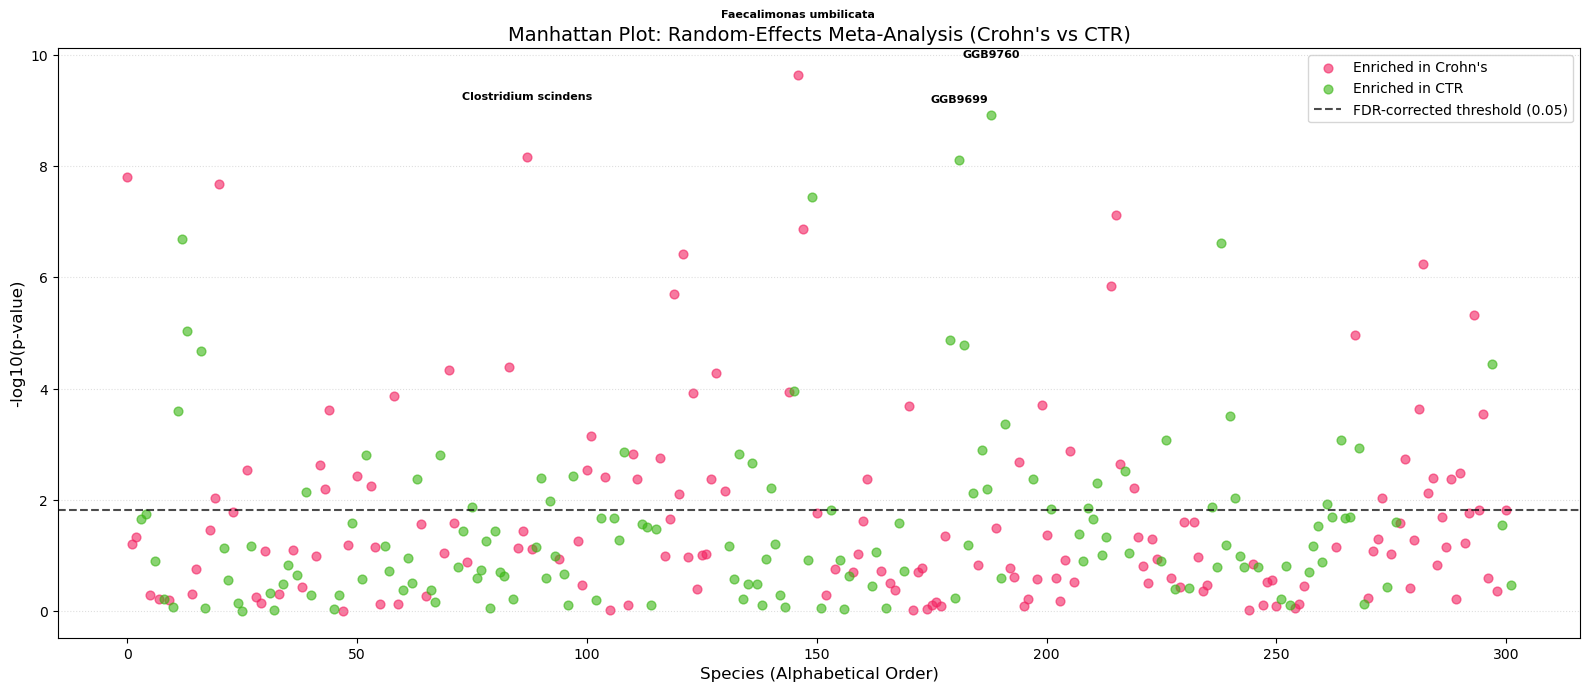

In [20]:
# --- Manhattan plot: random-effects meta-analysis ---
meta_df['-log10P'] = -np.log10(meta_df['P_value'])
meta_df_sorted = meta_df.sort_values('Species').reset_index(drop=True)
meta_df_sorted['Index'] = meta_df_sorted.index

fdr_line_p = meta_df_sorted[meta_df_sorted['FDR_P'] < 0.05]['P_value'].max()

plt.figure(figsize=(16, 7))

crohns_pts = meta_df_sorted[meta_df_sorted['Beta_meta'] > 0]
ctr_pts    = meta_df_sorted[meta_df_sorted['Beta_meta'] <= 0]

plt.scatter(crohns_pts['Index'], crohns_pts['-log10P'],
            c='#f32261', alpha=0.6, s=40, label="Enriched in Crohn's")
plt.scatter(ctr_pts['Index'], ctr_pts['-log10P'],
            c='#3ab614', alpha=0.6, s=40, label='Enriched in CTR')

plt.axhline(-np.log10(fdr_line_p), color='black', linestyle='--',
            alpha=0.7, label='FDR-corrected threshold (0.05)')

top5 = meta_df_sorted.nsmallest(5, 'P_value')
for _, row in top5.iterrows():
    name = row['Species'].replace('s__','').replace('_',' ')
    plt.text(row['Index'], row['-log10P'] + 1, name,
             fontsize=8, ha='center', va='bottom', fontweight='bold')

plt.title("Manhattan Plot: Random-Effects Meta-Analysis (Crohn's vs CTR)", fontsize=14)
plt.xlabel('Species (Alphabetical Order)', fontsize=12)
plt.ylabel('-log10(p-value)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('/home/valerie/Desktop/Master/metagenomics/HW4/output/meta_manhattan.png', dpi=300)
plt.show()

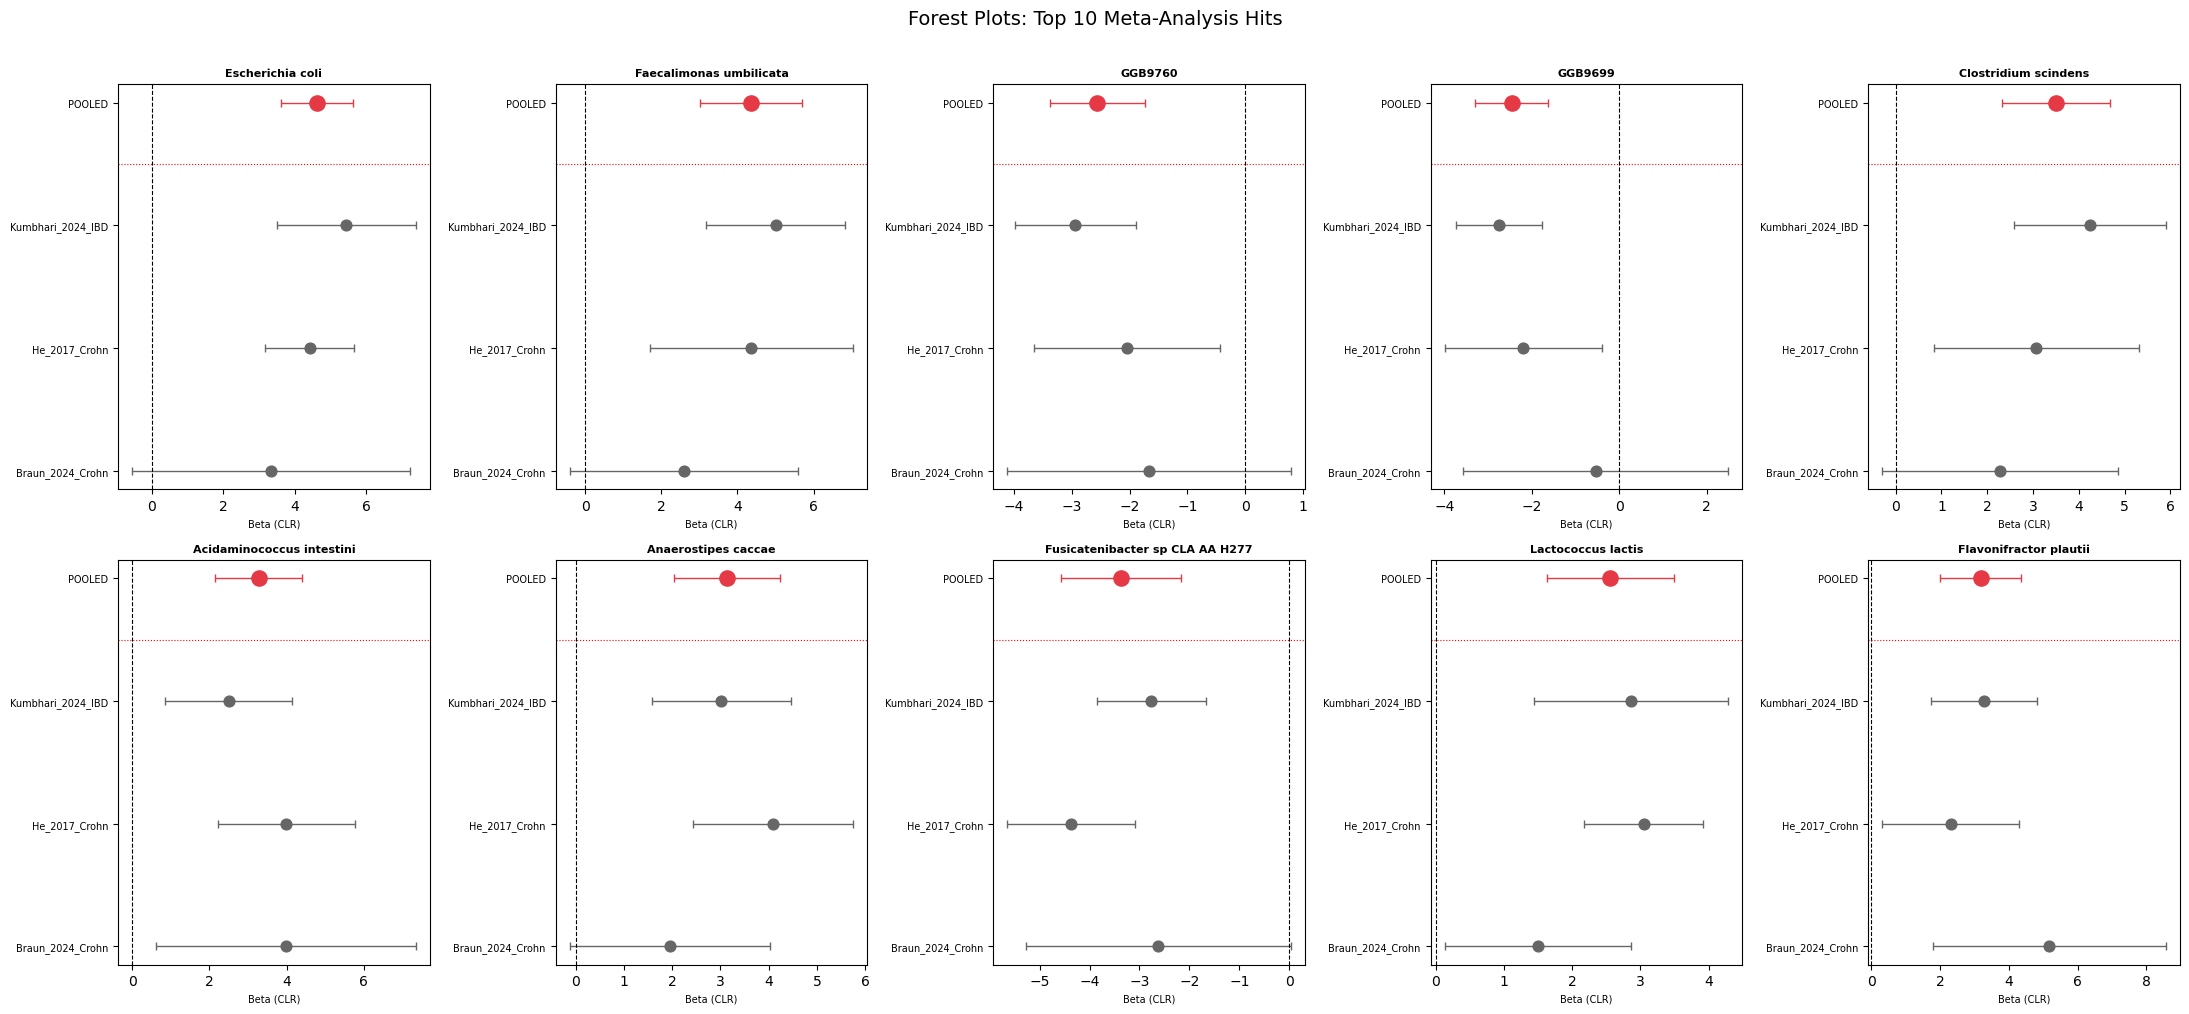

In [22]:
# --- Forest plot for top 10 species ---
top10_species = meta_df.head(10)['Species'].tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for ax_i, species in enumerate(top10_species):
    ax = axes[ax_i]
    betas_plot, ses_plot, cohort_labels = [], [], []
    
    for cohort, res_df in cohort_results.items():
        row = res_df[res_df['Species'] == species]
        if not row.empty:
            betas_plot.append(row['Beta'].values[0])
            ses_plot.append(row['SE'].values[0])
            cohort_labels.append(cohort)
    
    # Add pooled meta estimate
    meta_row = meta_df[meta_df['Species'] == species]
    if not meta_row.empty:
        betas_plot.append(meta_row['Beta_meta'].values[0])
        ses_plot.append(meta_row['SE_meta'].values[0])
        cohort_labels.append('POOLED')
    
    y_pos = list(range(len(betas_plot)))
    colors_fp = ['#666666'] * (len(betas_plot) - 1) + ['#e63946']
    sizes_fp  = [60] * (len(betas_plot) - 1) + [120]
    
    for y, b, se, col, sz in zip(y_pos, betas_plot, ses_plot, colors_fp, sizes_fp):
        ax.errorbar(b, y, xerr=1.96*se, fmt='o',
                    color=col, markersize=sz**0.5, capsize=3, linewidth=1)
    
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cohort_labels, fontsize=7)
    ax.set_title(species.replace('s__','').replace('_',' '), fontsize=8, fontweight='bold')
    ax.set_xlabel('Beta (CLR)', fontsize=7)
    ax.axhline(len(betas_plot) - 1.5, color='red', linewidth=0.8, linestyle=':')

plt.suptitle('Forest Plots: Top 10 Meta-Analysis Hits', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/home/valerie/Desktop/Master/metagenomics/HW4/output/forest_plots.png', dpi=300, bbox_inches='tight')
plt.show()

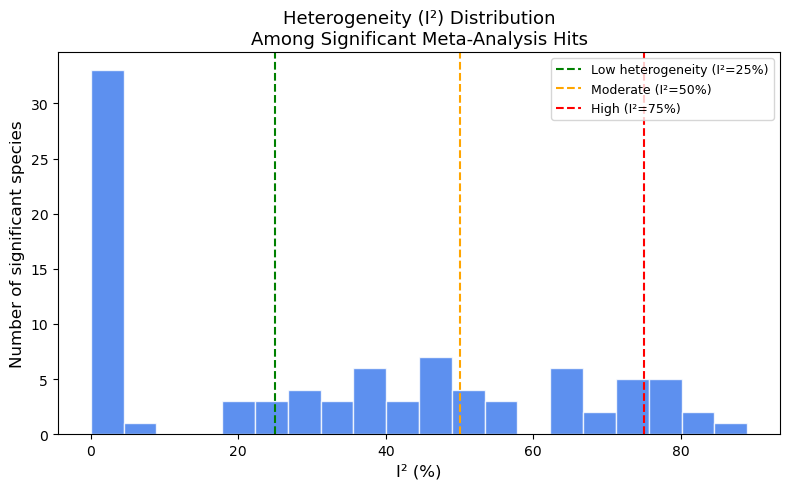

Median I2 among significant species: 31.6%
Species with I2 > 75% (high heterogeneity): 8


In [24]:
# --- Heterogeneity summary: I2 distribution ---
plt.figure(figsize=(8, 5))
sig_meta = meta_df[meta_df['FDR_P'] < 0.05]

plt.hist(sig_meta['I2'], bins=20, color='#3575eb', edgecolor='white', alpha=0.8)
plt.axvline(25, color='green',  linestyle='--', label='Low heterogeneity (I²=25%)')
plt.axvline(50, color='orange', linestyle='--', label='Moderate (I²=50%)')
plt.axvline(75, color='red',    linestyle='--', label='High (I²=75%)')
plt.xlabel('I² (%)', fontsize=12)
plt.ylabel('Number of significant species', fontsize=12)
plt.title('Heterogeneity (I²) Distribution\nAmong Significant Meta-Analysis Hits', fontsize=13)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/home/valerie/Desktop/Master/metagenomics/HW4/output/heterogeneity_I2.png', dpi=300)
plt.show()

print(f'Median I2 among significant species: {sig_meta["I2"].median():.1f}%')
print(f'Species with I2 > 75% (high heterogeneity): {(sig_meta["I2"] > 75).sum()}')

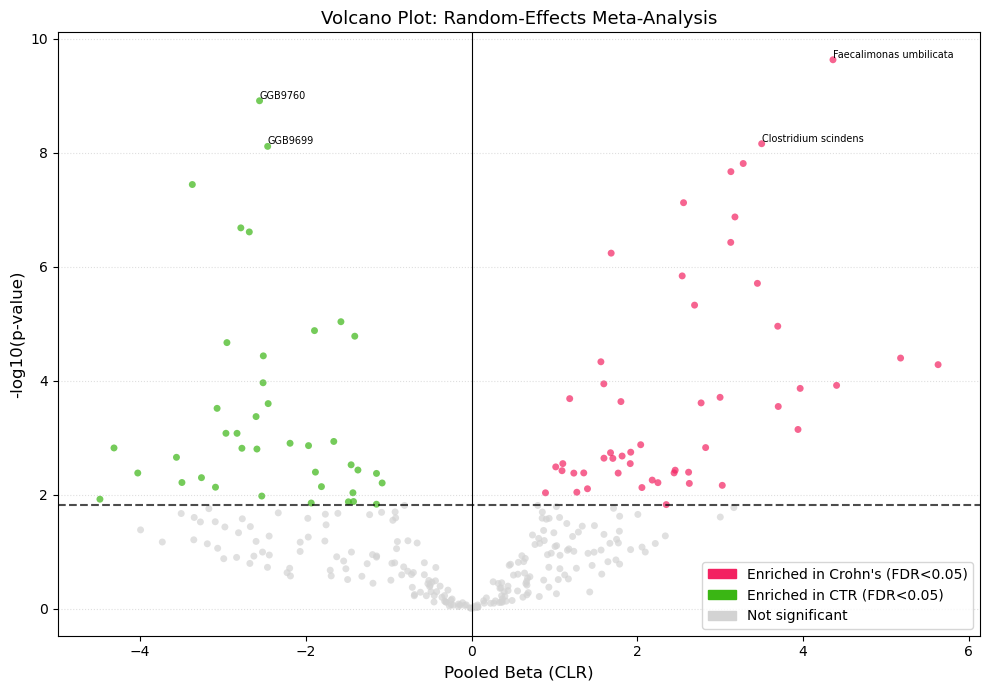

In [26]:
# --- Volcano plot: meta-analysis ---
meta_df['-log10P'] = -np.log10(meta_df['P_value'])

def meta_color(row):
    if row['FDR_P'] < 0.05:
        return '#f32261' if row['Beta_meta'] > 0 else '#3ab614'
    return 'lightgrey'

meta_df['color'] = meta_df.apply(meta_color, axis=1)

fdr_line = meta_df[meta_df['FDR_P'] < 0.05]['-log10P'].min() if (meta_df['FDR_P'] < 0.05).any() else None

plt.figure(figsize=(10, 7))
plt.scatter(meta_df['Beta_meta'], meta_df['-log10P'],
            c=meta_df['color'], alpha=0.7, s=25, edgecolors='none')

plt.axvline(0, color='black', linewidth=0.8)
if fdr_line:
    plt.axhline(fdr_line, color='black', linestyle='--', alpha=0.7, label='FDR < 0.05')

top5 = meta_df.nsmallest(5, 'P_value')
for _, row in top5.iterrows():
    name = row['Species'].replace('s__','').replace('_',' ')
    plt.text(row['Beta_meta'], row['-log10P'], name,
             fontsize=7, ha='left', va='bottom')

enriched  = mpatches.Patch(color='#f32261', label="Enriched in Crohn's (FDR<0.05)")
depleted  = mpatches.Patch(color='#3ab614', label='Enriched in CTR (FDR<0.05)')
nonsig    = mpatches.Patch(color='lightgrey', label='Not significant')
plt.legend(handles=[enriched, depleted, nonsig], loc='lower right')

plt.title("Volcano Plot: Random-Effects Meta-Analysis", fontsize=13)
plt.xlabel('Pooled Beta (CLR)', fontsize=12)
plt.ylabel('-log10(p-value)', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('/home/valerie/Desktop/Master/metagenomics/HW4/output/meta_volcano.png', dpi=300)
plt.show()

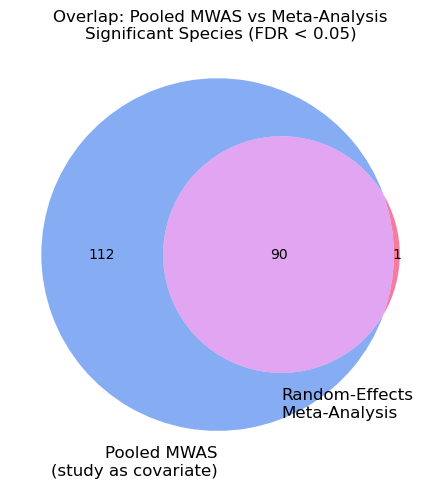

Pooled only: 112
Meta only: 1
Shared: 90


In [28]:
# --- Overlap: HW3 MWAS vs Meta-analysis ---
try:
    from matplotlib_venn import venn2
    hw3_sig = set(pooled_df[pooled_df['FDR_P'] < 0.05]['Species'])
    meta_sig = set(meta_df[meta_df['FDR_P'] < 0.05]['Species'])

    plt.figure(figsize=(7, 5))
    venn2([hw3_sig, meta_sig],
          set_labels=('Pooled MWAS\n(study as covariate)', 'Random-Effects\nMeta-Analysis'),
          set_colors=('#3575eb', '#f32261'), alpha=0.6)
    plt.title('Overlap: Pooled MWAS vs Meta-Analysis\nSignificant Species (FDR < 0.05)', fontsize=12)
    plt.tight_layout()
    plt.savefig('/home/valerie/Desktop/Master/metagenomics/HW4/output/meta_venn.png', dpi=300)
    plt.show()
    print(f'Pooled only: {len(hw3_sig - meta_sig)}')
    print(f'Meta only: {len(meta_sig - hw3_sig)}')
    print(f'Shared: {len(hw3_sig & meta_sig)}')
except ImportError:
    print('matplotlib-venn not installed. Run: pip install matplotlib-venn')

In [30]:
# --- Save results tables ---
meta_df.drop(columns='color', errors='ignore').to_csv('/home/valerie/Desktop/Master/metagenomics/HW4/output/meta_analysis_results.csv', index=False)
pooled_df.to_csv('/home/valerie/Desktop/Master/metagenomics/HW4/output/pooled_mwas_results.csv', index=False)

print('Results saved to output/meta_analysis_results.csv')
print('Results saved to output/pooled_mwas_results.csv')
print('\n=== Meta-Analysis Summary ===')
print(f'Cohorts included         : {len(cohort_results)}')
print(f'Species tested           : {len(meta_df)}')
print(f'Sig. (pooled model)      : {(pooled_df["FDR_P"] < 0.05).sum()}')
print(f'Sig. (random-effects)    : {(meta_df["FDR_P"] < 0.05).sum()}')
print(f'Consistent across both   : {len(set(pooled_df[pooled_df["FDR_P"]<0.05]["Species"]) & set(meta_df[meta_df["FDR_P"]<0.05]["Species"]))}')

Results saved to output/meta_analysis_results.csv
Results saved to output/pooled_mwas_results.csv

=== Meta-Analysis Summary ===
Cohorts included         : 3
Species tested           : 302
Sig. (pooled model)      : 202
Sig. (random-effects)    : 91
Consistent across both   : 90
